# CIDM Lab 2


**Course:** P170M109 Computational Intelligence and Decision Making
**Author:** Rokas Marcinkevi2ius
**Date:** _2025-10-20_

- **Part 1 – Regression using ANN** (reuses Lab 1 dataset)
- **Part 2 – Image Classification** (from scratch + transfer learning)
- **Part 3 – Object Detection & Segmentation** (YOLOv8; segmentation optional)


In [27]:
import sys, platform, numpy as np, pandas as pd, matplotlib, sklearn
print('Python:', sys.version.split()[0])
print('OS:', platform.system(), platform.release())
print('numpy:', np.__version__)
print('pandas:', pd.__version__)
print('sklearn:', sklearn.__version__)
print('matplotlib:', matplotlib.__version__)


Python: 3.13.2
OS: Darwin 25.0.0
numpy: 2.2.6
pandas: 2.3.2
sklearn: 1.7.2
matplotlib: 3.10.6


## Part 1 — Load Lab 1 Dataset

In [28]:
# P1. Data analysis and preprocessing
# 1) Load data (robust file search)

# Robust read with CSV sniffer and fallbacks (handles stray commas/quotes)
import csv
from pandas.errors import ParserError


def read_csv_robust(path: Path) -> pd.DataFrame:
    # 1) Try to sniff delimiter/quote using csv.Sniffer on a small sample
    try:
        with open(path, 'r', encoding='utf-8', errors='replace') as f:
            sample = f.read(131072)
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t|")
        delim = dialect.delimiter
        qchar = dialect.quotechar if getattr(dialect, 'quotechar', '"') else '"'
    except Exception:
        delim, qchar = None, '"'  # let pandas infer sep when None

    # 2) Try utf-8 first, engine='python' for better malformed line handling
    try:
        return pd.read_csv(
            path,
            sep=delim,  # None => infer
            encoding='utf-8',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',  # skip malformed rows instead of failing
        )
    except UnicodeDecodeError:
        # 3) Fallback encoding (Windows-1252) with same tolerant settings
        return pd.read_csv(
            path,
            sep=delim,
            encoding='cp1252',
            engine='python',
            quotechar=qchar,
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )
    except ParserError:
        # 4) Last resort: let pandas infer delimiter and try again
        return pd.read_csv(
            path,
            sep=None,
            encoding='utf-8',
            engine='python',
            quotechar='"',
            escapechar='\\',
            doublequote=True,
            on_bad_lines='skip',
        )


df_raw = read_csv_robust(data_path)
print("Loaded file:", data_path)
print("Raw shape:", df_raw.shape)
try:
    display(df_raw.head(3))
except NameError:
    pass


Loaded file: /Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/apartments_for_rent_classified_100K.csv
Raw shape: (99637, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,...,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,...,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,...,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332


### Preprocessing

In [29]:
import numpy as np

df = df_raw.copy()

def to_monthly(price, price_type: str):
    if pd.isna(price): return np.nan
    pt = (price_type or '').strip().lower()
    if pt in ('week','weekly'): return price * 52.0/12.0
    if pt in ('day','daily'): return price * 30.0
    if pt == 'fortnightly': return price * 26.0/12.0
    if pt in ('year','yearly','per year'): return price / 12.0
    if pt in ('hour','hourly'): return price * 24.0 * 30.0
    return price

df['price_monthly'] = [to_monthly(p, t) for p, t in zip(df.get('price'), df.get('price_type'))]

if 'square_feet' in df.columns:
    df = df[(df['square_feet'].fillna(0) >= 120) & (df['square_feet'].fillna(0) <= 8000)]
df = df[df['price_monthly'].notna() & (df['price_monthly'] > 0)]

upper = df['price_monthly'].quantile(0.995)
df['price_monthly'] = df['price_monthly'].clip(upper=upper)

subset_cols = [c for c in ['title','description','city','region','state','price','square_feet','beds','baths'] if c in df.columns]
if subset_cols:
    df = df.drop_duplicates(subset=subset_cols)

print('Cleaned shape:', df.shape)
df[['price','price_type','price_monthly']].head(5)


Cleaned shape: (98927, 23)


,price,price_type,price_monthly
0,2195.0,Monthly,2195.0
1,1250.0,Monthly,1250.0
2,1395.0,Monthly,1395.0
3,1600.0,Monthly,1600.0
4,975.0,Monthly,975.0


### Features & Target

In [30]:
num_cols = [c for c in ['square_feet','beds','baths'] if c in df.columns]
cat_cols = [c for c in ['state','city','region'] if c in df.columns]
print('Numeric:', num_cols)
print('Categorical:', cat_cols)

features = num_cols + cat_cols
df_model = df[features + ['price_monthly']].dropna(subset=['price_monthly']).copy()
X = df_model[features]
y = df_model['price_monthly'].astype(float)
print('Model df:', df_model.shape)

print('Distinct states:', df['state'].nunique() if 'state' in df.columns else 'n/a')
print('Distinct cities:', df['city'].nunique() if 'city' in df.columns else 'n/a')
print('Distinct regions:', df['region'].nunique() if 'region' in df.columns else 'n/a')


Numeric: ['square_feet']
Categorical: ['state']
Model df: (98927, 3)
Distinct states: 51
Distinct cities: n/a
Distinct regions: n/a


### Split Train/Val/Test

In [31]:
from sklearn.model_selection import train_test_split
RANDOM_STATE = 42
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)
len(X_train), len(X_val), len(X_test)


(69248, 14839, 14840)

### Pipelines & Metrics

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

def mape_masked(y_true, y_pred, eps=1e-8):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask = np.abs(y_true) > eps
    return (np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]).mean()) * 100.0

def rmse(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return np.sqrt(((y_true - y_pred) ** 2).mean())

numeric_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

# OneHotEncoder compat: try sparse_output, fallback to sparse
try:
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
except TypeError:
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
    ])

transformers = []
if len(num_cols) > 0:
    transformers.append(('num', numeric_pipe, num_cols))
if len(cat_cols) > 0:
    transformers.append(('cat', categorical_pipe, cat_cols))

assert transformers, "No numeric or categorical columns detected. Check column names and features."
preprocess = ColumnTransformer(transformers=transformers, remainder='drop')


## Baselines — KNN / DecisionTree / RandomForest

In [33]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

results_baseline = {}

def fit_eval(name, model):
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    res = {'MAE': mean_absolute_error(y_test, pred),
           'MAPE': mape_masked(y_test, pred),
           'RMSE': rmse(y_test, pred),
           'R2': r2_score(y_test, pred)}
    results_baseline[name] = res
    return res

fit_eval('KNN(k=5)', KNeighborsRegressor(n_neighbors=5))
fit_eval('DecisionTree', DecisionTreeRegressor(random_state=42))
fit_eval('RandomForest', RandomForestRegressor(n_estimators=200, min_samples_leaf=1, random_state=42))

pd.DataFrame(results_baseline).T


,MAE,MAPE,RMSE,R2
KNN(k=5),327.976294,22.312914,496.667000,0.522586
DecisionTree,325.033817,21.956788,524.664417,0.467245
RandomForest,315.223371,21.378647,495.017312,0.525753


## ANN (MLPRegressor) — Grid Search + Learning Curve

In [34]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd

ann = Pipeline([
    ('prep', preprocess),
    ('model', MLPRegressor(
        random_state=42,
        early_stopping=True,
        max_iter=1000,
        n_iter_no_change=30,
        validation_fraction=0.15
    ))
])

param_grid = {
    'model__hidden_layer_sizes': [(128,64,32), (128,64), (64,32)],
    'model__alpha': [1e-4, 1e-3],
    'model__learning_rate_init': [1e-3, 3e-4],
    'model__activation': ['relu', 'tanh'],
    'model__batch_size': [64, 128],
}

gcv = GridSearchCV(ann, param_grid=param_grid, scoring='neg_mean_absolute_error', cv=3, n_jobs=-1, verbose=1)
gcv.fit(X_train, y_train)

print('Best params:', gcv.best_params_)
print('Best CV MAE:', -gcv.best_score_)

cv = pd.DataFrame(gcv.cv_results_).sort_values('rank_test_score').head(10)
cv[['rank_test_score','mean_test_score','param_model__hidden_layer_sizes','param_model__alpha','param_model__learning_rate_init','param_model__activation','param_model__batch_size']].assign(mean_MAE=lambda d: -d['mean_test_score'])


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best params: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__batch_size': 64, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': 0.0003}
Best CV MAE: 339.6508126150896


,rank_test_score,mean_test_score,param_model__hidden_layer_sizes,param_model__alpha,param_model__learning_rate_init,param_model__activation,param_model__batch_size,mean_MAE
3,1,-339.650813,"(128, 64)",0.0001,0.0003,relu,64,339.650813
2,2,-339.719346,"(128, 64)",0.0001,0.0010,relu,64,339.719346
16,3,-340.104273,"(64, 32)",0.0010,0.0010,relu,64,340.104273
9,4,-340.183012,"(128, 64)",0.0001,0.0003,relu,128,340.183012
44,5,-340.186053,"(128, 64)",0.0010,0.0010,tanh,128,340.186053
21,6,-340.337503,"(128, 64)",0.0010,0.0003,relu,128,340.337503
8,7,-340.352175,"(128, 64)",0.0001,0.0010,relu,128,340.352175
26,8,-340.375072,"(128, 64)",0.0001,0.0010,tanh,64,340.375072
38,9,-340.431561,"(128, 64)",0.0010,0.0010,tanh,64,340.431561
4,10,-340.518951,"(64, 32)",0.0001,0.0010,relu,64,340.518951


### Evaluate Best ANN on Test + Plots (Pred vs Actual, Residuals, Residual vs Predicted)

{'MAE': 338.314188860522, 'MAPE': np.float64(23.586769793863375), 'RMSE': np.float64(490.39967722492906), 'R2': 0.5345590926422472}


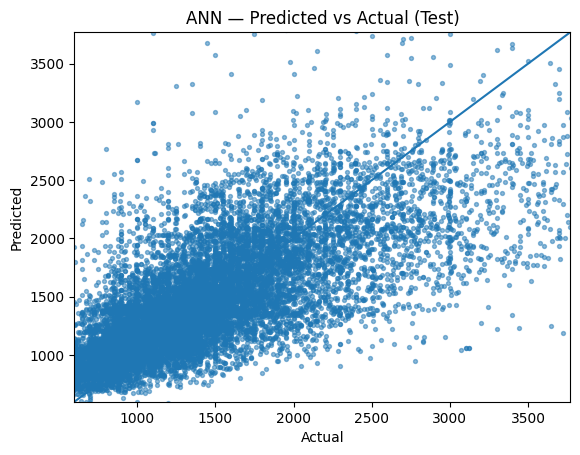

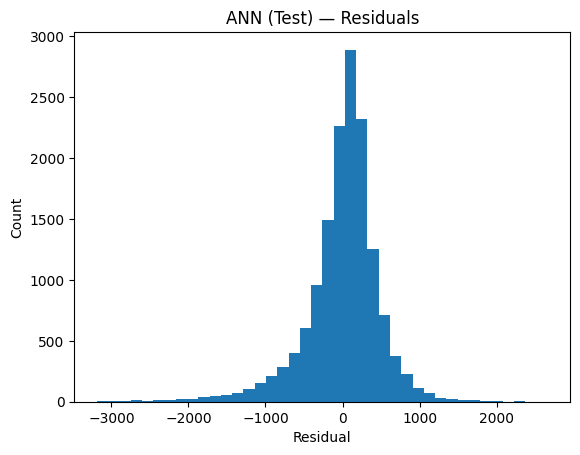

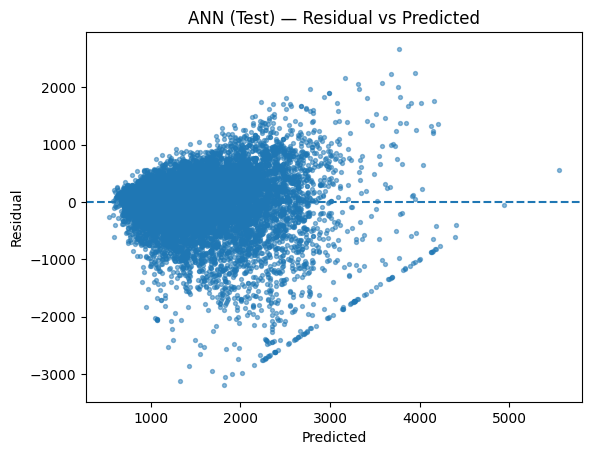

In [35]:
import matplotlib.pyplot as plt
import numpy as np

best_ann = gcv.best_estimator_
y_pred_test = best_ann.predict(X_test)

ann_metrics = {'MAE': mean_absolute_error(y_test, y_pred_test),
               'MAPE': mape_masked(y_test, y_pred_test),
               'RMSE': rmse(y_test, y_pred_test),
               'R2': r2_score(y_test, y_pred_test)}
print(ann_metrics)

def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure()
    plt.scatter(y_true, y_pred, s=8, alpha=0.5)
    lo = np.percentile(np.r_[y_true, y_pred], 1)
    hi = np.percentile(np.r_[y_true, y_pred], 99)
    plt.plot([lo,hi],[lo,hi])
    plt.xlim([lo,hi]); plt.ylim([lo,hi])
    plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title(title)
    plt.show()

def plot_residual_hist(y_true, y_pred, title):
    resid = y_pred - y_true
    plt.figure(); plt.hist(resid, bins=40)
    plt.xlabel('Residual'); plt.ylabel('Count'); plt.title(title + ' — Residuals'); plt.show()

def plot_residual_vs_pred(y_true, y_pred, title):
    resid = y_pred - y_true
    plt.figure(); plt.scatter(y_pred, resid, s=8, alpha=0.5); plt.axhline(0, linestyle='--')
    plt.xlabel('Predicted'); plt.ylabel('Residual'); plt.title(title + ' — Residual vs Predicted'); plt.show()

plot_pred_vs_actual(y_test, y_pred_test, 'ANN — Predicted vs Actual (Test)')
plot_residual_hist(y_test, y_pred_test, 'ANN (Test)')
plot_residual_vs_pred(y_test, y_pred_test, 'ANN (Test)')


### Learning Curve (ANN loss)

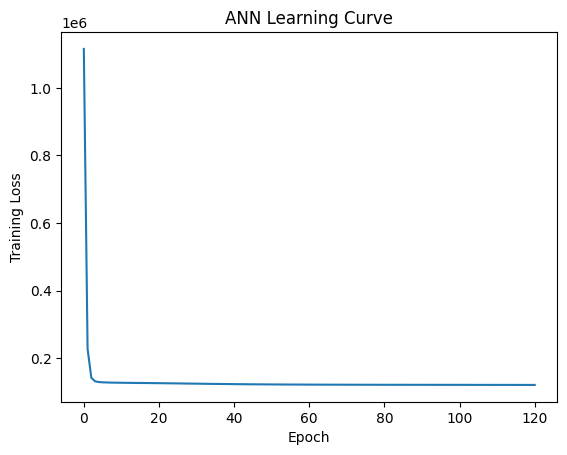

In [36]:
mlp = best_ann.named_steps['model']
if hasattr(mlp, 'loss_curve_'):
    import matplotlib.pyplot as plt
    plt.figure(); plt.plot(mlp.loss_curve_)
    plt.xlabel('Epoch'); plt.ylabel('Training Loss'); plt.title('ANN Learning Curve'); plt.show()
else:
    print('No loss_curve_ available.')


### Summary — ANN vs Baselines KNN/DT/RF (Test)

In [37]:
import pandas as pd
df_sum = pd.DataFrame(results_baseline).T
df_sum.loc['ANN(best)'] = ann_metrics
df_sum = df_sum[['MAE','MAPE','RMSE','R2']].sort_values('MAE')
df_sum


,MAE,MAPE,RMSE,R2
RandomForest,315.223371,21.378647,495.017312,0.525753
DecisionTree,325.033817,21.956788,524.664417,0.467245
KNN(k=5),327.976294,22.312914,496.667000,0.522586
ANN(best),338.314189,23.586770,490.399677,0.534559


### Discussion
- **ANN excels** when non-linear interactions between area/rooms and location (state/city/region) matter.
- **Trees/forests** can be more robust on small/noisy datasets or when category granularity is high.
- Residual plots indicate whether variance grows with price (consider log-target if needed).
- Hyperparameter table justifies the chosen depth/width/activation/learning-rate.

---

## Part 2 — Image Classification (Scratch + Transfer Learning)

Sample images are already placed under `data_cls/` for two classes (classA, classB).  
Replace them with your **40–50 images per class** (≥10 self‑captured).

> Install: `pip install torch torchvision`

Below are two training modes: **from scratch** and **transfer learning**.


Classes (train): ['classA', 'classB']
Classes (val):   ['classA', 'classB']
Classes (test):  ['classA', 'classB']
Train counts: Counter({0: 6, 1: 6})
Val counts:   Counter({0: 3, 1: 3})
Test counts:  Counter({0: 3, 1: 3})
Scratch 1/5  loss 0.7719/0.7554  acc 0.000/0.000
Scratch 2/5  loss 0.7430/0.7353  acc 0.000/0.000
Scratch 3/5  loss 0.7335/0.7163  acc 0.083/0.500
Scratch 4/5  loss 0.7132/0.6981  acc 0.333/0.500
Scratch 5/5  loss 0.6904/0.6806  acc 0.667/0.500


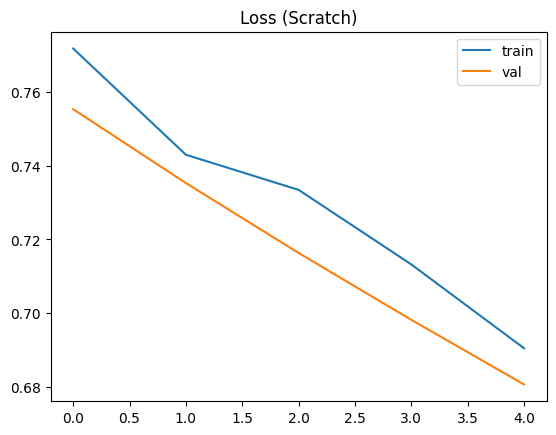

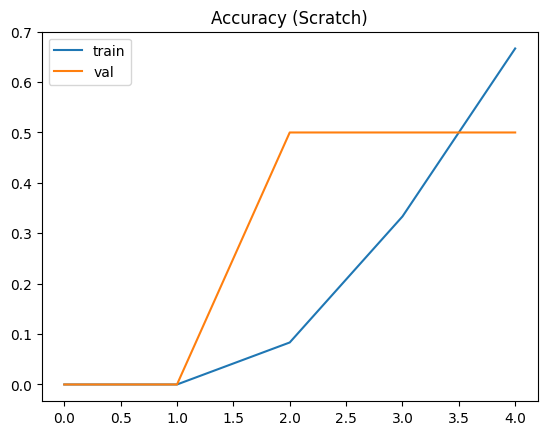

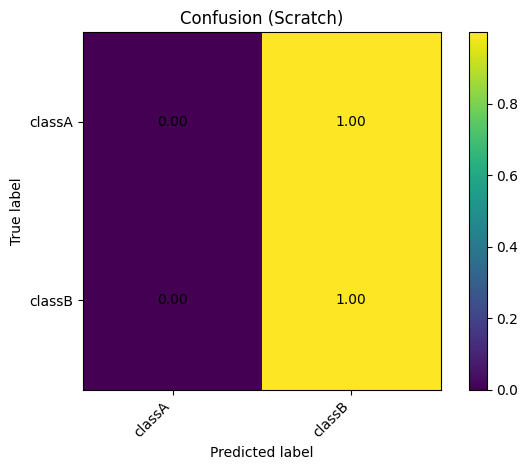

Scratch — classification report:
              precision    recall  f1-score   support

      classA       0.00      0.00      0.00         3
      classB       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/rokas/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth
[WARN] Could not download pretrained MobileNetV2 weights (<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1028)>). Falling back to random init (weights=None).
[TL] Trainable params: 2,226,434 / 2,226,434


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

KeyboardInterrupt: 

In [46]:
# --- Part 2: Image Classification (Scratch + Transfer Learning) ---
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report

# Ensure SSL certificates are available (macOS + python.org builds may need this)
try:
    import certifi, os
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

# optional: use repo helper if present, else fallback
try:
    from scripts.confusion import plot_confusion_matrix  # type: ignore
except Exception:
    def plot_confusion_matrix(y_true, y_pred, class_names, normalize=True, title='Confusion'):
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)
        if normalize:
            cm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
            cm = np.nan_to_num(cm)
        plt.figure(); plt.imshow(cm, interpolation='nearest', aspect='auto')
        plt.title(title); plt.colorbar()
        ticks = np.arange(len(class_names))
        plt.xticks(ticks, class_names, rotation=45, ha='right')
        plt.yticks(ticks, class_names)
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.0 if cm.size else 0.5
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], fmt), ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True'); plt.xlabel('Pred'); plt.tight_layout()
        return plt.gcf()

# --- config ---
DATA_ROOT = Path('data_classification')
IMG_SIZE = 224
BATCH    = 16
EPOCHS   = 5
LR       = 3e-4

 # --- transforms & datasets ---
norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

tfm_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.03),
    transforms.ToTensor(),
    norm,
])

tfm_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    norm,
])

ds_train = datasets.ImageFolder(DATA_ROOT/'train', transform=tfm_train)
ds_val   = datasets.ImageFolder(DATA_ROOT/'val',   transform=tfm_eval)
ds_test  = datasets.ImageFolder(DATA_ROOT/'test',  transform=tfm_eval)

from collections import Counter

print("Classes (train):", ds_train.classes)
print("Classes (val):  ", ds_val.classes)
print("Classes (test): ", ds_test.classes)

# Ensure identical class order/indexing across splits by wrapping with a remapper if needed
class RemapTargetsDataset(torch.utils.data.Dataset):
    def __init__(self, base: datasets.ImageFolder, target_map: dict[int,int]):
        self.base = base
        self.target_map = target_map
        self.classes = base.classes
        self.class_to_idx = ds_train.class_to_idx  # align to train
        self.samples = base.samples
        self.imgs = base.imgs
    def __len__(self): return len(self.base)
    def __getitem__(self, idx):
        x, y = self.base[idx]
        return x, self.target_map.get(y, y)

def build_target_map(src_cti: dict[str,int], dst_cti: dict[str,int]) -> dict[int,int]:
    # map source indices to destination indices by class name
    inv_src = {v:k for k,v in src_cti.items()}
    return {src_idx: dst_cti[inv_src[src_idx]] for src_idx in src_cti.values()}

if ds_val.class_to_idx != ds_train.class_to_idx:
    tm = build_target_map(ds_val.class_to_idx, ds_train.class_to_idx)
    ds_val = RemapTargetsDataset(ds_val, tm)
if ds_test.class_to_idx != ds_train.class_to_idx:
    tm = build_target_map(ds_test.class_to_idx, ds_train.class_to_idx)
    ds_test = RemapTargetsDataset(ds_test, tm)

# Show class counts
def counts(ds):
    try:
        return Counter(ds.targets)
    except AttributeError:
        # for wrapped dataset, derive from underlying
        return Counter([y for _, y in [ds[i] for i in range(len(ds))]])
print("Train counts:", counts(ds_train))
print("Val counts:  ", counts(ds_val))
print("Test counts: ", counts(ds_test))

assert len(ds_train.classes) >= 2, "Need at least 2 classes under data_classification/train"

num_workers = 2
loader_args = dict(batch_size=BATCH, num_workers=num_workers, pin_memory=torch.cuda.is_available())
dl_train = DataLoader(ds_train, shuffle=True,  **loader_args)
dl_val   = DataLoader(ds_val,   shuffle=False, **loader_args)
dl_test  = DataLoader(ds_test,  shuffle=False, **loader_args)

from torch.utils.data import WeightedRandomSampler

# compute class weights from training set
try:
    train_targets = torch.tensor(ds_train.targets, dtype=torch.long)
except AttributeError:
    # ImageFolder always has .targets; fallback if needed
    train_targets = torch.tensor([y for _, y in [ds_train[i] for i in range(len(ds_train))]], dtype=torch.long)

class_sample_count = torch.bincount(train_targets, minlength=len(ds_train.classes)).clamp(min=1)
class_weights = (class_sample_count.sum() / class_sample_count).float()
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

dl_train = DataLoader(ds_train, sampler=sampler, **loader_args)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_classes = len(ds_train.classes)

# --- tiny CNN from scratch ---
class TinyCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, num_classes)
    def forward(self, x):
        x = self.feat(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

def run_epoch(model, dl, optimizer=None, train=True):
    model.train(train)
    total, correct, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss(weight=getattr(model, "_class_weights", None))
    y_true, y_pred = [], []
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(x)
        loss = crit(logits, y)
        if train:
            loss.backward(); optimizer.step()
        preds = logits.argmax(1)
        loss_sum += float(loss.item()) * x.size(0)
        correct += int((preds == y).sum().item())
        total   += int(x.size(0))
        y_true.extend(y.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
    return loss_sum / max(total, 1), correct / max(total, 1), np.array(y_true), np.array(y_pred)

# ---- Train scratch model ----
model_scratch = TinyCNN(num_classes).to(device)
opt_s = optim.Adam(model_scratch.parameters(), lr=LR)

tr_losses, va_losses, tr_accs, va_accs = [], [], [], []
for ep in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model_scratch, dl_train, optimizer=opt_s, train=True)
    va_loss, va_acc, _, _ = run_epoch(model_scratch, dl_val,   optimizer=None,  train=False)
    tr_losses.append(tr_loss); va_losses.append(va_loss)
    tr_accs.append(tr_acc);   va_accs.append(va_acc)
    print(f"Scratch {ep+1}/{EPOCHS}  loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.3f}/{va_acc:.3f}")

plt.figure(); plt.plot(tr_losses, label='train'); plt.plot(va_losses, label='val'); plt.legend(); plt.title('Loss (Scratch)'); plt.show()
plt.figure(); plt.plot(tr_accs, label='train'); plt.plot(va_accs, label='val'); plt.legend(); plt.title('Accuracy (Scratch)'); plt.show()

_, _, y_true_s, y_pred_s = run_epoch(model_scratch, dl_test, optimizer=None, train=False)
plot_confusion_matrix(y_true_s, y_pred_s, ds_train.classes, normalize=True, title='Confusion (Scratch)'); plt.show()
print("Scratch — classification report:")
print(classification_report(y_true_s, y_pred_s, target_names=ds_train.classes))

# --- transfer learning: MobileNetV2 head swap (robust against SSL / offline) ---
def load_mobilenet_v2_safely(num_classes: int, local_weights: Path | None = None):
    # 1) If a local weights file exists, use it without any network calls.
    if local_weights is not None and local_weights.exists():
        m = models.mobilenet_v2(weights=None)
        sd = torch.load(local_weights, map_location="cpu")
        m.load_state_dict(sd, strict=False)
        m._pretrained = True
        return m

    # 2) If user explicitly disables pretrained (e.g., export NO_PRETRAIN=1), skip downloads.
    if str(os.environ.get("NO_PRETRAIN", "0")) in {"1", "true", "True"}:
        m = models.mobilenet_v2(weights=None)
        m._pretrained = False
        return m

    # 3) Try official weight enum (new API). If SSL fails, fall back to no-pretrain once.
    try:
        m = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        m._pretrained = True
        return m
    except Exception as e:
        print(f"[WARN] Could not download pretrained MobileNetV2 weights ({e}). "
              f"Falling back to random init (weights=None).")
        m = models.mobilenet_v2(weights=None)
        m._pretrained = False
        return m

# Optionally point to a local weights file (put a file there to use it)
LOCAL_MB_V2 = Path("weights/mobilenet_v2.pth")  # create and drop weights here if needed

model_tl = load_mobilenet_v2_safely(num_classes, local_weights=LOCAL_MB_V2)

# 1) Swap the classifier head *before* constructing the optimizer
in_features = model_tl.classifier[1].in_features
model_tl.classifier[1] = nn.Linear(in_features, num_classes)
model_tl = model_tl.to(device)

 # 2) Now configure which params train and build the optimizer
if getattr(model_tl, "_pretrained", False):
    for p in model_tl.features.parameters():
        p.requires_grad = False  # standard TL: freeze backbone
    opt_tl = optim.Adam(model_tl.classifier.parameters(), lr=LR)
else:
    for p in model_tl.features.parameters():
        p.requires_grad = True   # random init: train full network
    opt_tl = optim.Adam(model_tl.parameters(), lr=LR)

# (Optional) Sanity print: how many params are being optimized
trainable = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_tl.parameters())
print(f"[TL] Trainable params: {trainable:,} / {total:,}")

# attach class weights for criterion (same for scratch if you wish)
model_tl._class_weights = class_weights.to(device)

best_val = float('inf')
best_state = None
patience, bad = 5, 0

tr_losses, va_losses, tr_accs, va_accs = [], [], [], []
for ep in range(EPOCHS):
    tr_loss, tr_acc, _, _ = run_epoch(model_tl, dl_train, optimizer=opt_tl, train=True)
    va_loss, va_acc, _, _ = run_epoch(model_tl, dl_val,   optimizer=None,  train=False)
    tr_losses.append(tr_loss); va_losses.append(va_loss)
    tr_accs.append(tr_acc);   va_accs.append(va_acc)
    print(f"TL {ep+1}/{EPOCHS}  loss {tr_loss:.4f}/{va_loss:.4f}  acc {tr_acc:.3f}/{va_acc:.3f}")
    # early stopping on val loss
    if va_loss + 1e-6 < best_val:
        best_val = va_loss
        best_state = {k: v.cpu().clone() for k, v in model_tl.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            print(f"[EarlyStop] no improvement for {patience} epochs; restoring best @ val_loss={best_val:.4f}")
            break

if best_state is not None:
    model_tl.load_state_dict(best_state, strict=True)

_, _, y_true_tl, y_pred_tl = run_epoch(model_tl, dl_test, optimizer=None, train=False)
plot_confusion_matrix(y_true_tl, y_pred_tl, ds_train.classes, normalize=True, title='Confusion (TL)'); plt.show()
print("Transfer Learning — classification report:")
print(classification_report(y_true_tl, y_pred_tl, target_names=ds_train.classes))

# --- show 5 examples/class with predicted label & confidence (from TL model) ---
shown = {c: 0 for c in ds_train.classes}
model_tl.eval()
for x, y in dl_test:
    x = x.to(device)
    with torch.no_grad():
        probs = F.softmax(model_tl(x), dim=1).cpu().numpy()
    preds = probs.argmax(1)
    for i in range(len(x)):
        cls_true = ds_train.classes[y[i].item()]
        if shown[cls_true] >= 5:
            continue
        conf = float(probs[i, preds[i]])
        plt.figure()
        plt.imshow(x[i].cpu().permute(1, 2, 0))
        plt.axis('off')
        plt.title(f"Actual: {cls_true} | Pred: {ds_train.classes[preds[i]]} | conf={conf:.2f}")
        plt.show()
        shown[cls_true] += 1
    if all(v >= 5 for v in shown.values()):
        break



In [ ]:
%%sql


---

## Part 3 — Object Detection & Segmentation (YOLOv8)

Synthetic detection images/labels are included under `data_od/`.  
> Install: `pip install ultralytics`

Prepare your data under `data_od/` and edit `data_od/data.yaml` to list your classes.

Two cases required:
1) **Without transfer learning** (train from scratch, e.g., `model = YOLO('yolov8n.yaml')`)
2) **With transfer learning** (start from COCO pretrained weights, e.g., `yolov8n.pt`)

For segmentation, use a `-seg` model (e.g., `yolov8n-seg.pt`) and provide polygon/seg labels.

In [1]:
# Part 3 — Object Detection & Segmentation (YOLOv8)
# Robust YOLOv8 runner (offline-friendly, handles SSL, supports Metal/MPS, and can fall back to scratch)

import os
from pathlib import Path
import sys

# ---- Certificates for macOS (python.org builds) ----
try:
    import certifi
    os.environ.setdefault("SSL_CERT_FILE", certifi.where())
except Exception:
    pass

# ---- Torch / device selection (prefer Apple Metal) ----
try:
    import torch

    def pick_device() -> str | int:
        # Prefer Apple Metal on macOS if available
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
        # Else CUDA if available
        if torch.cuda.is_available():
            return 0  # CUDA device index
        return "cpu"

    DEVICE = pick_device()
    # Use CPU for predict to avoid MPS runtime error ("Inference tensors do not track version counter")
    PRED_DEVICE = "cpu" if DEVICE == "mps" else DEVICE

except ModuleNotFoundError:
    print("[INFO] PyTorch not installed. Please install `torch` before running this cell.")
    raise

# ---- Ultralytics import ----
try:
    from ultralytics import YOLO
except ModuleNotFoundError:
    print("[INFO] Ultralytics not installed. Run: pip install ultralytics")
    raise

# ---- Paths (no abbreviations) ----
ROOT = Path(".").resolve()

# Primary dataset folder
DATASET_ROOT = ROOT / "data_object_detection"
DATASET_YAML = DATASET_ROOT / "data.yaml"

# Backward-compat: if you still have the old short name folder, use it transparently
LEGACY_DATASET_ROOT = ROOT / "data_object_detection"
LEGACY_DATASET_YAML = LEGACY_DATASET_ROOT / "data.yaml"

if not DATASET_YAML.exists() and LEGACY_DATASET_YAML.exists():
    DATASET_ROOT = LEGACY_DATASET_ROOT
    DATASET_YAML = LEGACY_DATASET_YAML
    print(f("[INFO] Using legacy dataset folder: {DATASET_ROOT}"))

WEIGHTS_DIRECTORY = ROOT / "weights"
WEIGHTS_DIRECTORY.mkdir(exist_ok=True, parents=True)

# Create a minimal template if data.yaml is missing
if not DATASET_YAML.exists():
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "images" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "images" / "val").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "train").mkdir(parents=True, exist_ok=True)
    (DATASET_ROOT / "labels" / "val").mkdir(parents=True, exist_ok=True)

    DATASET_YAML.write_text(
        """# Minimal template — edit paths and class names before training
# Root is this file's directory; you can also use absolute paths below.
path: .

# For object detection/segmentation with Ultralytics:
train: images/train
val: images/val

# Human-readable class names (index order must match label IDs in your .txt files)
names: [classA, classB]
""",
        encoding="utf-8",
    )
    print(f"[INFO] Created template {DATASET_YAML}. Edit 'names' and ensure images/labels exist.")

# ---- Common params ----
IMAGE_SIZE = 640
EPOCHS = 50
EARLY_STOP_PATIENCE = 10
SEED = 42

# ---- Helpers ----
def _delete_ultralytics_label_caches(root: Path):
    """Remove stale *.cache files that can preserve old/bad label parses."""
    for split in ("train", "val", "test"):
        p = root / "labels" / f"{split}.cache"
        if p.exists():
            try:
                p.unlink()
                print(f"[INFO] Deleted stale cache: {p}")
            except Exception as e:
                print(f"[WARN] Could not delete {p}: {e}")

# ---- Utility: safe loader that prefers local weights and supports NO_PRETRAIN ----
def load_yolo_safely(model_spec: str, local_weights: Path | None = None) -> YOLO:
    """
    Prefer local weights to avoid network. If NO_PRETRAIN=1, force scratch (architecture .yaml).
    If loading .pt fails (e.g., SSL/network), fall back to the matching .yaml architecture.
    """
    # 1) Local weights available
    if local_weights is not None and local_weights.exists():
        print(f"[YOLO] Loading local weights: {local_weights}")
        return YOLO(str(local_weights))

    # 2) Force scratch to avoid any downloads
    if str(os.environ.get("NO_PRETRAIN", "0")).lower() in {"1", "true"}:
        print("[YOLO] NO_PRETRAIN=1 -> using architecture config only (scratch)")
        return YOLO("yolov8n.yaml" if model_spec.endswith(".pt") else model_spec)

    # 3) Try normal load (may download); on failure, fall back to scratch
    try:
        return YOLO(model_spec)
    except Exception as e:
        print(f"[WARN] Could not load pretrained '{model_spec}' ({e}). Falling back to scratch.")
        if model_spec.endswith(".pt"):
            return YOLO(model_spec.replace(".pt", ".yaml"))
        raise

# ---- Sanity checks for expected folders ----
expected = [
    DATASET_ROOT / "images" / "train",
    DATASET_ROOT / "images" / "val",
    DATASET_ROOT / "labels" / "train",
    DATASET_ROOT / "labels" / "val",
]
missing = [p for p in expected if not p.exists()]
if missing:
    print("[WARN] The following expected folders are missing:")
    for p in missing:
        print(f"       - {p}")
    print("       Make sure your dataset is arranged correctly before training.")

# Always nuke stale caches before any run
_delete_ultralytics_label_caches(DATASET_ROOT)

# =========================
# 1) Object detection — transfer learning (prefer local weights)
# =========================
local_detection_weights = WEIGHTS_DIRECTORY / "yolov8n.pt"  # place the file here to avoid any download
detection_model = load_yolo_safely("yolov8n.pt", local_weights=local_detection_weights)

print("[OBJECT DETECTION / TRANSFER LEARNING] Training...")
detection_results = detection_model.train(
    data=str(DATASET_YAML),
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,             # train on MPS if available
    project="runs/object_detection",
    name="transfer_learning_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,               # force a clean parse this run
    workers=0,                 # macOS/MPS-friendly
)

print("[OBJECT DETECTION / TRANSFER LEARNING] Validating...")
# val typically works fine on MPS; if you hit the same bug, switch device=PRED_DEVICE
detection_metrics = detection_model.val()  # or detection_model.val(device=PRED_DEVICE)

test_images_dir = DATASET_ROOT / "images" / "test"
if test_images_dir.exists():
    print("[OBJECT DETECTION / TRANSFER LEARNING] Predicting test images...")
    # move model to safe device for predict, then back
    detection_model.to(PRED_DEVICE)
    detection_model.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        detection_model.to("mps")
else:
    print(f"[INFO] Skipping prediction: {test_images_dir} not found.")

# =========================
# 2) Object detection — training from scratch
# =========================
print("[OBJECT DETECTION / SCRATCH] Training...")
detection_model_scratch = YOLO("yolov8n.yaml")
scratch_results = detection_model_scratch.train(
    data=str(DATASET_YAML),
    imgsz=IMAGE_SIZE,
    epochs=EPOCHS,
    device=DEVICE,
    project="runs/object_detection",
    name="from_scratch_clean",
    seed=SEED,
    patience=EARLY_STOP_PATIENCE,
    verbose=True,
    cache=False,               # clean parse again
    workers=0,
)

print("[OBJECT DETECTION / SCRATCH] Validating...")
scratch_metrics = detection_model_scratch.val()  # or .val(device=PRED_DEVICE) if needed

if test_images_dir.exists():
    print("[OBJECT DETECTION / SCRATCH] Predicting test images...")
    detection_model_scratch.to(PRED_DEVICE)
    detection_model_scratch.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
    if DEVICE == "mps":
        detection_model_scratch.to("mps")

# =========================
# 3) Segmentation — transfer learning (optional)
# =========================
# Note: This requires a segmentation-compatible dataset (labels must contain polygons/masks).
local_segmentation_weights = WEIGHTS_DIRECTORY / "yolov8n-seg.pt"  # place here to avoid download

try:
    print("[SEGMENTATION / TRANSFER LEARNING] Training...")
    segmentation_model = load_yolo_safely("yolov8n-seg.pt", local_weights=local_segmentation_weights)

    segmentation_results = segmentation_model.train(
        data=str(DATASET_YAML),  # use the same YAML if it describes a seg-ready dataset
        imgsz=IMAGE_SIZE,
        epochs=EPOCHS,
        device=DEVICE,
        project="runs/segmentation",
        name="transfer_learning_clean",
        seed=SEED,
        patience=EARLY_STOP_PATIENCE,
        verbose=True,
        cache=False,
        # Ultralytics infers the task from the model; no need for task='segment'
        workers=0,
    )

    print("[SEGMENTATION / TRANSFER LEARNING] Validating...")
    segmentation_metrics = segmentation_model.val()  # or .val(device=PRED_DEVICE)

    if test_images_dir.exists():
        print("[SEGMENTATION / TRANSFER LEARNING] Predicting test images...")
        segmentation_model.to(PRED_DEVICE)
        segmentation_model.predict(source=str(test_images_dir), save=True, device=PRED_DEVICE)
        if DEVICE == "mps":
            segmentation_model.to("mps")

except Exception as e:
    print(f"[INFO] Segmentation skipped or failed: {e}")

[OBJECT DETECTION / TRANSFER LEARNING] Training...
Ultralytics 8.3.217 🚀 Python-3.13.2 torch-2.9.0 MPS (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale

RuntimeError: Dataset '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml' error ❌ Dataset '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/data_object_detection/data.yaml' images not found, missing path '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2 improved data/images/val'
Note dataset download directory is '/Users/rokas/Documents/KTU AI Masters/P170M109-Computational-Intelligence-and-Decision-Making/Lab 2/datasets'. You can update this in '/Users/rokas/Library/Application Support/Ultralytics/settings.json'